In [1]:
# Data cleaning
# EDA
# Text Preprocessing
# Modelbuilding
# Evaluation
# Improvement
# Website
# Deploy

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud

In [3]:
df = pd.read_csv('IMDB Dataset.csv')

In [4]:
df.sample(5)

,review,sentiment
40230,it's amazing that so many people that i know h...,positive
38798,Many people has got a film they think of as th...,positive
34282,This movie wants to elaborate that criminals a...,negative
19828,In the fifties the age restrictions for films ...,positive
35082,After looking for this Bruceploitation for mon...,negative


### 1. Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df = df.drop_duplicates(keep='first')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [11]:
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df.iloc[:,1])

In [12]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [13]:
def remove_html_tags(text):
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()

In [14]:
df['review'] = df['review'].apply(remove_html_tags)

C:\Users\vikas\AppData\Local\Temp\ipykernel_22540\704213473.py:2: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [15]:
def remove_links(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [16]:
df['review'] = df['review'].apply(remove_links)

In [17]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. The filming tec...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


### 2. EDA

In [18]:
df['sentiment'].value_counts()

sentiment
1    24884
0    24698
Name: count, dtype: int64

In [19]:
# data is balanced

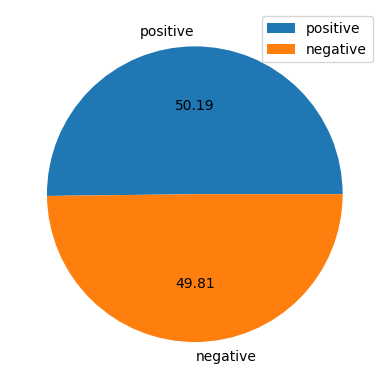

In [20]:
plt.Figure(figsize=(12,8))
plt.pie(df['sentiment'].value_counts(),labels=['positive','negative'],autopct='%0.2f')
plt.legend()
plt.show()

In [21]:
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vikas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vikas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
df['num_characters'] = df['review'].apply(len)

In [23]:
df['num_words'] = df['review'].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df['num_sentences'] = df['review'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [25]:
df.head()

,review,sentiment,num_characters,num_words,num_sentences
0,One of the other reviewers has mentioned that ...,1,1725,353,10
1,A wonderful little production. The filming tec...,1,962,177,7
2,I thought this was a wonderful way to spend ti...,1,902,187,4
3,Basically there's a family where a little boy ...,0,712,148,6
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1269,248,9


In [26]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,49582.000000,49582.000000,49582.000000
mean,1286.132266,262.052136,10.782724
std,972.092774,194.084550,7.855326
min,32.000000,8.000000,1.000000
25%,689.000000,143.000000,6.000000
50%,954.000000,197.000000,9.000000
75%,1560.000000,318.000000,13.000000
max,13584.000000,2730.000000,282.000000


In [50]:
df[df['sentiment']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,24884.000000,24884.000000,24884.000000
mean,1302.550635,263.501085,10.494856
std,1014.093380,200.762345,7.768136
min,65.000000,11.000000,1.000000
25%,682.000000,141.000000,6.000000
50%,952.000000,196.000000,9.000000
75%,1585.000000,320.250000,13.000000
max,13584.000000,2730.000000,282.000000


In [ ]:
# positive sentiment contains-->more number of characters,words and sentences

In [51]:
df[df['sentiment']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,24698.000000,24698.000000,24698.000000
mean,1269.590250,260.592275,11.072759
std,927.581847,187.108329,7.931802
min,32.000000,8.000000,1.000000
25%,696.000000,145.000000,6.000000
50%,956.500000,198.000000,9.000000
75%,1536.000000,315.000000,13.000000
max,8681.000000,1732.000000,126.000000


In [52]:
# negative sentiment contains-->less number of characters,words and sentences in comparison to positive sentiment review

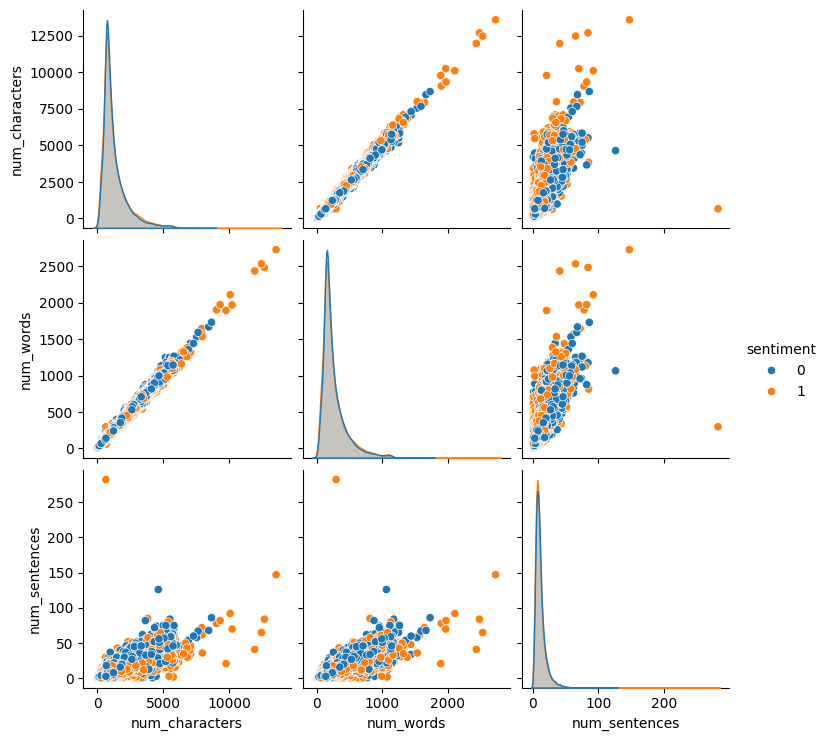

In [28]:
sns.pairplot(df,hue='sentiment')

<Axes: >

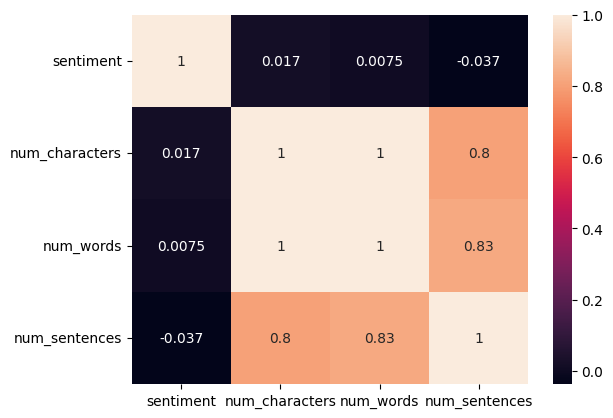

In [29]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

### 3. Data Preprocessing
* Lower Case
* Tokenization
* Removing Special Character
* Removing stopwords and Punctuations
* Stemming

In [30]:
def transformed_text(text):
    
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [31]:
ps = PorterStemmer()

In [32]:
df['transformed_text'] = df['review'].apply(transformed_text)

In [33]:
df.head()

,review,sentiment,num_characters,num_words,num_sentences,transformed_text
0,One of the other reviewers has mentioned that ...,1,1725,353,10,one review mention watch 1 oz episod hook righ...
1,A wonderful little production. The filming tec...,1,962,177,7,wonder littl product film techniqu fashion giv...
2,I thought this was a wonderful way to spend ti...,1,902,187,4,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,712,148,6,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1269,248,9,petter mattei love time money visual stun film...


In [34]:
new_df = df.copy()

In [35]:
new_df.head()

,review,sentiment,num_characters,num_words,num_sentences,transformed_text
0,One of the other reviewers has mentioned that ...,1,1725,353,10,one review mention watch 1 oz episod hook righ...
1,A wonderful little production. The filming tec...,1,962,177,7,wonder littl product film techniqu fashion giv...
2,I thought this was a wonderful way to spend ti...,1,902,187,4,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,0,712,148,6,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1269,248,9,petter mattei love time money visual stun film...


In [36]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review            49582 non-null  object
 1   sentiment         49582 non-null  int64 
 2   num_characters    49582 non-null  int64 
 3   num_words         49582 non-null  int64 
 4   num_sentences     49582 non-null  int64 
 5   transformed_text  49582 non-null  object
dtypes: int64(4), object(2)
memory usage: 2.6+ MB


In [4]:
# new_df.to_csv("cleaned.csv")

In [ ]:
# new_df = df.copy()

In [3]:
new_df = pd.read_csv('cleaned.csv')

In [4]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [5]:
positive_wc = wc.generate(new_df[new_df['sentiment']==1]['transformed_text'].str.cat(sep=" "))

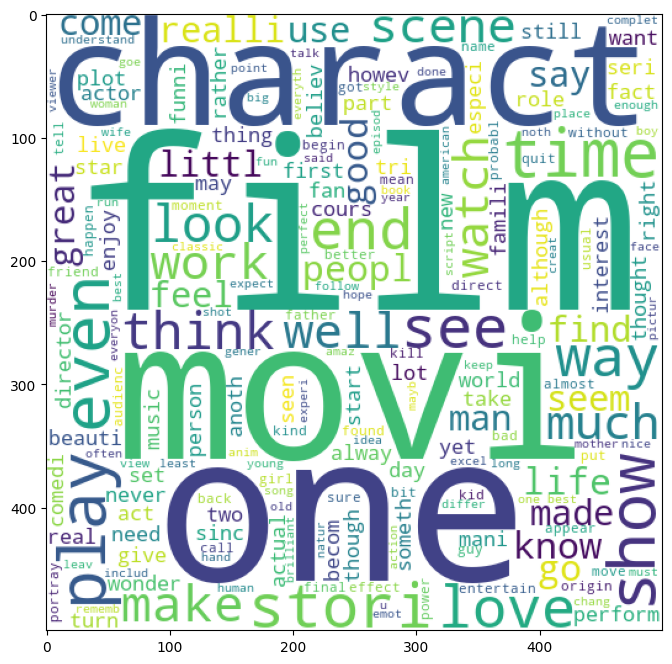

In [6]:
plt.figure(figsize=(12,8))
plt.imshow(positive_wc)
plt.show()

In [7]:
negative_wc = wc.generate(new_df[new_df['sentiment']==0]['transformed_text'].str.cat(sep=" "))

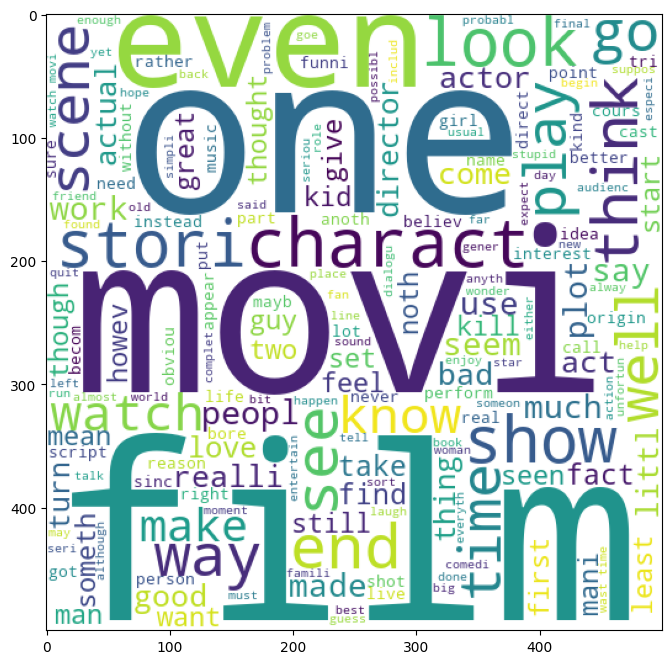

In [8]:
plt.figure(figsize=(12,8))
plt.imshow(negative_wc)
plt.show()

In [9]:
new_df.shape

(49582, 7)

In [10]:
new_df.memory_usage(deep=True).sum()/(1024**2)

np.float64(100.39968681335449)

In [11]:
new_df1 = new_df[new_df['sentiment']==1].sample(12000)

In [12]:
new_df2 = new_df[new_df['sentiment']==0].sample(12000)

In [13]:
temp = pd.concat([new_df1,new_df2]).sample(24000)

In [14]:
temp.head()

,Unnamed: 0,review,sentiment,num_characters,num_words,num_sentences,transformed_text
47220,47588,A couple(Janet and Richard) go camping out in ...,1,1468,319,15,coupl janet richard go camp wood near giant sw...
46683,47040,"Watching ""Plots with a View"" (called ""Undertak...",1,752,164,5,watch plot view call undertak betti us got fee...
20722,20798,I rented this movie from the library (it's har...,0,1104,237,12,rent movi librari hard find good reason pure c...
6653,6658,No awards show can please all the people. Clea...,1,1820,375,18,award show pleas peopl clearli favorit movi wi...
6068,6071,I thought this was an excellent and very hones...,1,240,47,3,thought excel honest portray paralysi racism m...


In [15]:
temp.drop(columns=['Unnamed: 0'],inplace=True)

In [16]:
temp.head()

,review,sentiment,num_characters,num_words,num_sentences,transformed_text
47220,A couple(Janet and Richard) go camping out in ...,1,1468,319,15,coupl janet richard go camp wood near giant sw...
46683,"Watching ""Plots with a View"" (called ""Undertak...",1,752,164,5,watch plot view call undertak betti us got fee...
20722,I rented this movie from the library (it's har...,0,1104,237,12,rent movi librari hard find good reason pure c...
6653,No awards show can please all the people. Clea...,1,1820,375,18,award show pleas peopl clearli favorit movi wi...
6068,I thought this was an excellent and very hones...,1,240,47,3,thought excel honest portray paralysi racism m...


### 4. Model Building

In [17]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import precision_score,confusion_matrix,accuracy_score

In [18]:
cv = CountVectorizer()

In [19]:
x1= cv.fit_transform(temp['transformed_text']).toarray()
(x1.nbytes)/(1024**2)

9351.37939453125

In [20]:
x1.shape

(24000, 51071)

In [21]:
x1

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(24000, 51071))

In [22]:
y1 = temp['sentiment'].values
y1

array([1, 1, 0, ..., 1, 0, 0], shape=(24000,))

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x1,y1,test_size=0.2,random_state=2)

In [24]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [25]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print("GNB Accuracy Score :",accuracy_score(y_test,y_pred1))
print("GNB Confusion Matrix :",confusion_matrix(y_test,y_pred1))
print("GNB Precision Score :",precision_score(y_test,y_pred1))

MemoryError: Unable to allocate 7.31 GiB for an array with shape (19200, 51071) and data type float64

In [68]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print("MNB Accuracy Score :",accuracy_score(y_test,y_pred2))
print("MNB Confusion Matrix :",confusion_matrix(y_test,y_pred2))
print("MNB Precision Score :",precision_score(y_test,y_pred2))

MNB Accuracy Score : 0.845
MNB Confusion Matrix : [[1066  172]
 [ 200  962]]
MNB Precision Score : 0.8483245149911817


In [69]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print("BNB Accuracy Score :",accuracy_score(y_test,y_pred3))
print("BNB Confusion Matrix :",confusion_matrix(y_test,y_pred3))
print("BNB Precision Score :",precision_score(y_test,y_pred3))

BNB Accuracy Score : 0.8275
BNB Confusion Matrix : [[1079  159]
 [ 255  907]]
BNB Precision Score : 0.850844277673546


In [97]:
# tfidf = TfidfVectorizer()
tfidf = TfidfVectorizer(max_features=2500)

In [98]:
x2 = tfidf.fit_transform(temp['transformed_text']).toarray()
x2

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.06619863, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(12000, 2500))

In [99]:
y2 = temp['sentiment'].values
y2

array([1, 0, 1, ..., 0, 1, 1], shape=(12000,))

In [92]:
x_train,x_test,y_train,y_test = train_test_split(x2,y2,test_size=0.2,random_state=2)

In [93]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [94]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print("GNB Accuracy Score :",accuracy_score(y_test,y_pred1))
print("GNB Confusion Matrix :",confusion_matrix(y_test,y_pred1))
print("GNB Precision Score :",precision_score(y_test,y_pred1))

GNB Accuracy Score : 0.7645833333333333
GNB Confusion Matrix : [[985 253]
 [312 850]]
GNB Precision Score : 0.7706255666364461


In [95]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print("MNB Accuracy Score :",accuracy_score(y_test,y_pred2))
print("MNB Confusion Matrix :",confusion_matrix(y_test,y_pred2))
print("MNB Precision Score :",precision_score(y_test,y_pred2))

MNB Accuracy Score : 0.8508333333333333
MNB Confusion Matrix : [[1054  184]
 [ 174  988]]
MNB Precision Score : 0.8430034129692833


In [96]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print("BNB Accuracy Score :",accuracy_score(y_test,y_pred3))
print("BNB Confusion Matrix :",confusion_matrix(y_test,y_pred3))
print("BNB Precision Score :",precision_score(y_test,y_pred3))

BNB Accuracy Score : 0.8391666666666666
BNB Confusion Matrix : [[1063  175]
 [ 211  951]]
BNB Precision Score : 0.844582593250444


In [2]:
import pickle

In [ ]:
pickle.dump()